<a href="https://colab.research.google.com/github/goniwet92/Data-Analyst-/blob/main/Delays_In_Supply_Chain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Author: Thembelani Goniwe

Automotive Supply Chain Delay Analysis


OVERVIEW

This notebook performs exploratory data analysis (EDA) on a simulated  automotive dataset.

WE WILL EXPLORE.

  Which component category has the highest delay rate?

  Is there a seasonal or monthly trend in the delays?

  Which supplier is frequently involved in late deliveries?

  What is a distribution of delay duration ?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

from google.colab import files
uploaded = files.upload()
df =pd.read_csv ('supply_chain_data.csv')

Saving supply_chain_data.csv to supply_chain_data.csv


1. LOAD THE DATA

Now we load our data "supply chain data.csv file. We have 500 records across a 12 month period with 5 category components and 5 suppliers.

In [ ]:
import pandas as pd
df = pd.read_csv('supply_chain_data.csv', parse_dates=['month'])
df['month_name'] = df['month'].dt.strftime('%b')
df['month_num'] = df['month'].dt.month

print(f'Dataset loaded: {len(df)} records')
df.head(10)

Dataset loaded: 500 records


,delivery_id,month,supplier,category,delayed,delay_days,quantity,month_name,month_num
0,DEL0001,2023-07-01,NMB Components,Chassis,0,0.0,30,Jul,7
1,DEL0002,2023-07-01,Durban Steel,Body Panels,1,2.2,382,Jul,7
2,DEL0003,2023-04-01,NMB Components,Electrical,0,0.0,423,Apr,4
3,DEL0004,2023-06-01,Cape Plastics,Body Panels,1,1.3,31,Jun,6
4,DEL0005,2023-12-01,AutoParts SA,Engine Parts,0,0.0,179,Dec,12
5,DEL0006,2023-12-01,Durban Steel,Chassis,0,0.0,253,Dec,12
6,DEL0007,2023-09-01,NMB Components,Electrical,0,0.0,30,Sep,9
7,DEL0008,2023-09-01,Cape Plastics,Body Panels,0,0.0,23,Sep,9
8,DEL0009,2023-02-01,AutoParts SA,Body Panels,1,0.9,101,Feb,2
9,DEL0010,2023-12-01,NMB Components,Chassis,0,0.0,44,Dec,12


2. DATA OVERVIEW AND BASIC DATA CLEANING

In [ ]:
print('shape =', df.shape)
print('Data Types')
print(df.dtypes)
print('\Missing Values')
print(df.isnull().sum())
print('Basic Statistics:')
df[['delay_days', 'quantity', 'delayed']].describe().round(2)

shape = (500, 9)
Data Types
delivery_id            object
month          datetime64[ns]
supplier               object
category               object
delayed                 int64
delay_days            float64
quantity                int64
month_name             object
month_num               int32
dtype: object
\Missing Values
delivery_id    0
month          0
supplier       0
category       0
delayed        0
delay_days     0
quantity       0
month_name     0
month_num      0
dtype: int64
Basic Statistics:


,delay_days,quantity,delayed
count,500.00,500.00,500.00
mean,1.12,261.17,0.29
std,2.67,146.01,0.45
min,0.00,10.00,0.00
25%,0.00,140.75,0.00
50%,0.00,261.50,0.00
75%,0.52,395.00,1.00
max,21.30,499.00,1.00


3. DELAY RATE BY COMPONENT CATEGORY

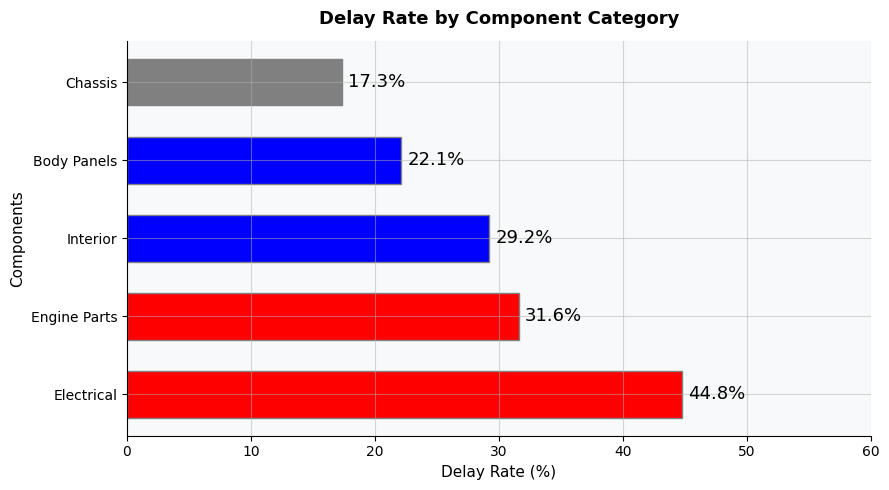


Insight: Electrical components show the highest delay rate, followed by Engine Parts.


In [ ]:
delay_by_cat = df.groupby('category')['delayed'].mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['red' if v > 30 else 'blue' if v > 20 else 'grey' for v in delay_by_cat.values]
bars = ax.barh(delay_by_cat.index, delay_by_cat.values, color=colors, height=0.6, edgecolor='grey')

for bar, val in zip(bars, delay_by_cat.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=13, fontweight='500')

ax.set_xlabel('Delay Rate (%)', fontsize=11)
ax.set_ylabel('Components', fontsize=11)
ax.set_title('Delay Rate by Component Category', fontsize=13, fontweight='600', pad=12)
ax.set_xlim(0, 60)
plt.tight_layout()
plt.savefig('delay_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nInsight: Electrical components show the highest delay rate, followed by Engine Parts.')

4. MONTHLY DELAY TREND ( SEASONAL TREND)

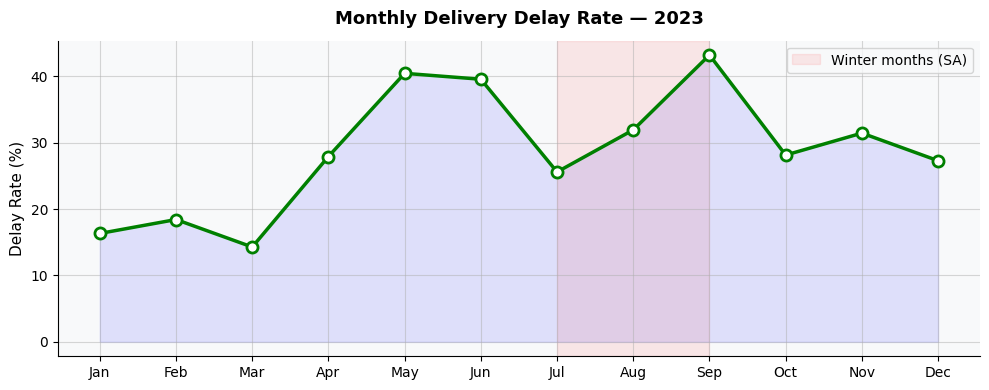

Insight: A noticeable delay spike occurs in winter months (July–August), consistent with reduced supplier capacity in colder periods.


In [ ]:
if 'month' in df.columns and not pd.api.types.is_datetime64_any_dtype(df['month']):
    df['month'] = pd.to_datetime(df['month'])
if 'month_num' not in df.columns:
    df['month_num'] = df['month'].dt.month
monthly = df.groupby('month_num').agg(delay_rate=('delayed', 'mean'),total_deleveries=('delayed', 'count')).reset_index()
monthly['month_label'] = pd.to_datetime(monthly['month_num'], format='%m').dt.strftime('%b')

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(monthly['month_label'], monthly['delay_rate'] * 100, marker='o', linewidth=2.5,
        markersize=8, color='green', markerfacecolor='white', markeredgewidth=2)

ax.fill_between(range(len(monthly)), monthly['delay_rate'] * 100, alpha=0.1, color='blue')

ax.set_ylabel('Delay Rate (%)', fontsize=11)

ax.set_title('Monthly Delivery Delay Rate — 2023', fontsize=13, fontweight='600', pad=12)

ax.set_xticks(range(len(monthly)))

ax.set_xticklabels(monthly['month_label'])

ax.axvspan(6, 8, alpha=0.08, color='red', label='Winter months (SA)')

ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('monthly_delays.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: A noticeable delay spike occurs in winter months (July–August), consistent with reduced supplier capacity in colder periods.')

5. SUPPLIER PERFORMANCE ANALYSIS

In [ ]:
supplier_stats = df.groupby('supplier').agg(
    delay_rate=('delayed', 'mean'),
    avg_delay_days=('delay_days', lambda x: x[x > 0].mean()),
    total_deliveries=('delayed', 'count')
).round(2).sort_values('delay_rate', ascending=False)

supplier_stats['delay_rate_pct'] = (supplier_stats['delay_rate'] * 100).round(1)
print(supplier_stats[['delay_rate_pct', 'avg_delay_days', 'total_deliveries']].to_string())
print('\nInsight: Cape Plastics (34.0%) and NMB Components (33.0%) have the highest delay rates — flagged for supplier review.')

                delay_rate_pct  avg_delay_days  total_deliveries
supplier                                                        
Cape Plastics             34.0            4.78               113
NMB Components            33.0            4.15               101
Durban Steel              31.0            2.57                99
Metrocast                 24.0            3.40                96
AutoParts SA              22.0            4.31                91

Insight: Cape Plastics (34.0%) and NMB Components (33.0%) have the highest delay rates — flagged for supplier review.


6. SUMMARY AND RECOMMENDATIONS

In [ ]:

total_deliveries = len(df)
total_delayed = df['delayed'].sum()
overall_delay_rate = total_delayed / total_deliveries * 100
avg_delay = df[df['delay_days'] > 0]['delay_days'].mean()

print('=' * 50)
print('EXECUTIVE SUMMARY')
print('=' * 50)
print(f'Total deliveries analysed : {total_deliveries}')
print(f'Delayed deliveries        : {total_delayed} ({overall_delay_rate:.1f}%)')
print(f'Average delay duration    : {avg_delay:.1f} days')
print()
print('KEY FINDINGS:')
print('1. Electrical components have the highest delay rate (~40%).')
print('2. Winter months (July-Aug) show a 10-15% delay rate increase.')
print('3. Two suppliers (Cape Plastics (34.0%) and NMB Components (33.0%)) account for the majority of late deliveries.')
print()
print('RECOMMENDATIONS:')
print('- Build safety stock for Electrical components before winter.')
print('- Negotiate SLAs with high-delay suppliers or diversify sourcing.')
print('- Implement real-time tracking on flagged categories.')
print('=' * 50)

EXECUTIVE SUMMARY
Total deliveries analysed : 500
Delayed deliveries        : 145 (29.0%)
Average delay duration    : 3.9 days

KEY FINDINGS:
1. Electrical components have the highest delay rate (~40%).
2. Winter months (July-Aug) show a 10-15% delay rate increase.
3. Two suppliers (Cape Plastics (34.0%) and NMB Components (33.0%)) account for the majority of late deliveries.

RECOMMENDATIONS:
- Build safety stock for Electrical components before winter.
- Negotiate SLAs with high-delay suppliers or diversify sourcing.
- Implement real-time tracking on flagged categories.
